## Пункт 1. Импорт библиотек.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Предобработка и модели
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Модели
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Настройка стилей
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

## Пункт 2. Загрузка данных и их первичный осмотр

In [4]:
# Загрузка данных
df = pd.read_csv('../data/movies_ready_for_ml.csv')
print('Колонки:', df.columns.tolist())

Колонки: ['id', 'title', 'vote_average', 'budget', 'revenue', 'runtime', 'popularity', 'vote_count', 'release_year', 'is_Action', 'is_Comedy', 'is_Drama', 'is_Horror', 'is_Romance', 'is_Thriller', 'is_SciFi', 'is_Crime', 'is_Adventure', 'is_Family', 'is_Animation', 'lang_en', 'lang_ru', 'lang_fr', 'lang_es', 'lang_de', 'lang_other']


In [5]:
# Размерность
print(f"\nРазмерность датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")


Размерность датасета: 5000 строк, 26 столбцов


In [6]:
# Первые строки
print("\nПервые 5 строк данных:")
display(df.head())


Первые 5 строк данных:


,id,title,vote_average,budget,revenue,runtime,popularity,vote_count,release_year,is_Action,...,is_Crime,is_Adventure,is_Family,is_Animation,lang_en,lang_ru,lang_fr,lang_es,lang_de,lang_other
0,1226863,The Super Mario Galaxy Movie,6.804,110000000.0,6.285898e+08,98.0,689.6183,475.0,2026.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1523145,Your Heart Will Be Broken,7.200,0.0,0.000000e+00,134.0,401.9712,61.0,2026.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,83533,Avatar: Fire and Ash,7.373,350000000.0,1.485988e+09,198.0,326.8193,2604.0,2025.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,687163,Project Hail Mary,8.215,200000000.0,5.102186e+08,157.0,271.2981,1462.0,2026.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1290417,Thrash,5.921,0.0,0.000000e+00,84.0,245.8304,277.0,2026.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# Типы данных
print("\nТипы данных столбцов:")
print(df.dtypes)


Типы данных столбцов:
id               object
title            object
vote_average    float64
budget          float64
revenue         float64
runtime         float64
popularity      float64
vote_count      float64
release_year    float64
is_Action       float64
is_Comedy       float64
is_Drama        float64
is_Horror       float64
is_Romance      float64
is_Thriller     float64
is_SciFi        float64
is_Crime        float64
is_Adventure    float64
is_Family       float64
is_Animation    float64
lang_en         float64
lang_ru         float64
lang_fr         float64
lang_es         float64
lang_de         float64
lang_other      float64
dtype: object


In [8]:
# Основные статистики
print("\nОписательные статистики:")
display(df.describe())


Описательные статистики:


,vote_average,budget,revenue,runtime,popularity,vote_count,release_year,is_Action,is_Comedy,is_Drama,...,is_Crime,is_Adventure,is_Family,is_Animation,lang_en,lang_ru,lang_fr,lang_es,lang_de,lang_other
count,4927.000000,4.927000e+03,4.927000e+03,4927.000000,4927.000000,4927.000000,4927.000000,4927.000000,4927.000000,4927.000000,...,4927.000000,4927.000000,4927.000000,4927.000000,4927.000000,4927.000000,4927.000000,4927.000000,4927.000000,4927.000000
mean,6.534034,3.408286e+07,1.154685e+08,107.557946,8.138472,3143.032474,2007.434341,0.324944,0.269129,0.404709,...,0.151005,0.218997,0.111224,0.120154,0.707733,0.007916,0.021717,0.020296,0.005886,0.236452
std,1.432066,5.216525e+07,2.185945e+08,28.663975,17.919994,4436.658099,59.401126,0.468402,0.443552,0.490885,...,0.358090,0.413609,0.314441,0.325175,0.454851,0.088626,0.145773,0.141026,0.076501,0.424946
min,0.000000,0.000000e+00,0.000000e+00,0.000000,1.543900,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.162500,0.000000e+00,0.000000e+00,94.500000,4.054900,247.500000,2001.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.764000,1.200000e+07,3.214426e+07,107.000000,5.108700,1651.000000,2013.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7.312000,4.500000e+07,1.363500e+08,122.000000,7.383650,4084.500000,2022.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,4.899000e+08,2.923706e+09,253.000000,689.618300,39385.000000,2029.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Целевая переменная vote_average имеет среднее значение 6.53 и медиану 6.76, что указывает на некоторое смещение распределения в сторону низких оценок. Бюджет, популярность и количество голосов характеризуются сильной правосторонней асимметрией (среднее значительно превышает медиану), что подтверждается наличием выбросов с экстремально высокими значениями.

Хронометраж большинства фильмов составляет около 107 минут, а основная масса данных относится к периоду после 2000 года. Среди жанров наиболее распространены Драма (40%) и Боевик (32%), а подавляющее большинство фильмов представлено на английском языке (71%).

In [9]:
# Проверка пропусков
print("\nПропуски в данных:")
print(df.isnull().sum())


Пропуски в данных:
id               0
title           73
vote_average    73
budget          73
revenue         73
runtime         73
popularity      73
vote_count      73
release_year    73
is_Action       73
is_Comedy       73
is_Drama        73
is_Horror       73
is_Romance      73
is_Thriller     73
is_SciFi        73
is_Crime        73
is_Adventure    73
is_Family       73
is_Animation    73
lang_en         73
lang_ru         73
lang_fr         73
lang_es         73
lang_de         73
lang_other      73
dtype: int64


В ходе первичного осмотра были изучены первые строки данных, типы столбцов (большинство числовые), получены основные описательные статистики и выявлено наличие 73 пропусков в каждой колонке. Для дальнейшего анализа и построения моделей необходимо обработать пропуски, создать дополнительные признаки (например, логарифмы бюджетов и голосов), проверить данные на выбросы и выполнить предобработку для подготовки к машинному обучению.

## Пункт 3. Предобработка данных

In [10]:
# Сохраняем исходный размер
initial_rows = df.shape[0]

# 1. Обработка пропусков
# Удаляем строки с любыми пропусками
df = df.dropna()

print(f"Удалено {5000 - len(df)} строк с пропусками")
print(f"Новый размер: {df.shape}")

Удалено 73 строк с пропусками
Новый размер: (4927, 26)


После анализа описательных статистик во 2 пункте мы обнаружили, что такие признаки, как budget, popularity и vote_count, имеют сильную правостороннюю асимметрию: их средние значения значительно превышают медианы, а разброс данных очень велик (от единиц до сотен миллионов). Такое распределение негативно влияет на многие модели машинного обучения, особенно на линейные.

Чтобы сделать распределение более близким к нормальному и уменьшить влияние экстремальных выбросов, мы применяем логарифмическое преобразование (np.log1p) к этим признакам. Это позволит модели лучше улавливать закономерности в данных.

In [11]:
# 2. Создание дополнительных признаков

# Логарифм бюджета (для нормализации распределения)
if 'budget' in df.columns:
    df['budget_log'] = np.log1p(df['budget'])

# Логарифм количества голосов
if 'vote_count' in df.columns:
    df['vote_count_log'] = np.log1p(df['vote_count'])

# Соотношение бюджет/популярность (может быть информативен, поскольку имеет в себе логику)
if 'budget' in df.columns and 'popularity' in df.columns:
    df['budget_per_popularity'] = df['budget'] / (df['popularity'] + 1)

In [12]:
def get_outliers_df(df, column):
    """Возвращает DataFrame с выбросами для указанного столбца"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers[['title', column, 'vote_average']].copy()

# Анализируем каждый числовой признак
for col in ['budget', 'popularity', 'vote_count', 'runtime', 'vote_average']:
    if col in df.columns:
        outliers_df = get_outliers_df(df, col)
        if len(outliers_df) > 0:
            print(f"\n--- {col} ---")
            print(f"Найдено выбросов: {len(outliers_df)}")
            print(outliers_df.to_string(index=False))
        else:
            print(f"\n--- {col}: выбросов не обнаружено ---")


--- budget ---
Найдено выбросов: 413
                                                   title      budget  vote_average
                                    Avatar: Fire and Ash 350000000.0         7.373
                                       Project Hail Mary 200000000.0         8.215
                                                 Hoppers 150000000.0         7.578
                                              Zootopia 2 150000000.0         7.600
                                 Spider-Man: No Way Home 200000000.0         7.934
                                            Interstellar 165000000.0         8.470
                                            The Avengers 220000000.0         7.999
                                                 Michael 170000000.0         5.800
                                Star Wars: The Last Jedi 300000000.0         6.755
                                  Avengers: Infinity War 300000000.0         8.234
                                  Jurassic World 

In [13]:
# 3. Проверка выбросов

# Функция для подсчета выбросов по методу IQR
def count_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers)

# Проверяем ключевые числовые столбцы на выбросы
for col in ['budget', 'popularity', 'vote_count', 'runtime']:
    if col in df.columns:
        n_outliers = count_outliers_iqr(df, col)
        if n_outliers > 0:
            print(f"   - {col}: {n_outliers} выбросов ({n_outliers/len(df)*100:.1f}%)")

print(f"\nРазмер данных после обработки: {df.shape[0]} строк, {df.shape[1]} столбцов")

   - budget: 413 выбросов (8.4%)
   - popularity: 481 выбросов (9.8%)
   - vote_count: 364 выбросов (7.4%)
   - runtime: 307 выбросов (6.2%)

Размер данных после обработки: 4927 строк, 29 столбцов


In [14]:
#НЕОБЯЗАТЕЛЬНО
#Посмотрим, какие строки являются выбросами по разным признакам
def get_outliers_df(df, column):
    """Возвращает DataFrame с выбросами для указанного столбца"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers[['title', column, 'vote_average']].copy()

# Анализируем каждый числовой признак
for col in ['budget', 'popularity', 'vote_count', 'runtime', 'vote_average']:
    if col in df.columns:
        outliers_df = get_outliers_df(df, col)
        if len(outliers_df) > 0:
            print(f"\n--- {col} ---")
            print(f"Найдено выбросов: {len(outliers_df)}")
            print(outliers_df.to_string(index=False))
        else:
            print(f"\n--- {col}: выбросов не обнаружено ---")


--- budget ---
Найдено выбросов: 413
                                                   title      budget  vote_average
                                    Avatar: Fire and Ash 350000000.0         7.373
                                       Project Hail Mary 200000000.0         8.215
                                                 Hoppers 150000000.0         7.578
                                              Zootopia 2 150000000.0         7.600
                                 Spider-Man: No Way Home 200000000.0         7.934
                                            Interstellar 165000000.0         8.470
                                            The Avengers 220000000.0         7.999
                                                 Michael 170000000.0         5.800
                                Star Wars: The Last Jedi 300000000.0         6.755
                                  Avengers: Infinity War 300000000.0         8.234
                                  Jurassic World 

In [15]:
# Важная чистка "мусора"
df = df[df['budget'] > 1000]          # Убираем "бесплатные" фильмы
df = df[df['vote_average'] > 0]       # Убираем фильмы без оценок
df = df[df['vote_count'] > 50]        # Оставляем только значимые оценки

В ходе предобработки данных мы удалили строки с пропусками, создали новые признаки (budget_log, vote_count_log, budget_per_popularity) и провели анализ выбросов по ключевым числовым признакам. Выбросы были обнаружены во всех рассматриваемых переменных (budget, popularity, vote_count, runtime, vote_average).

Логически выбросы мешают обучению модели, поскольку они смещают оценки коэффициентов (в линейных моделях) и могут заставить модель подстраиваться под редкие аномальные значения, ухудшая ее способность к обобщению на новых данных. Поэтому после анализа мы провели дополнительную фильтрацию: удалили фильмы с бюджетом менее 1000 (бесплатные/некорректные), с нулевым рейтингом и с малым количеством голосов (менее 50), чтобы оставить только статистически значимые наблюдения.

## Пункт 4. Исследовательский анализ данных

Проведем исследовательский анализ данных (EDA), чтобы визуально и статистически изучить распределение целевой переменной, взаимосвязи между признаками и выявить ключевые закономерности в данных.

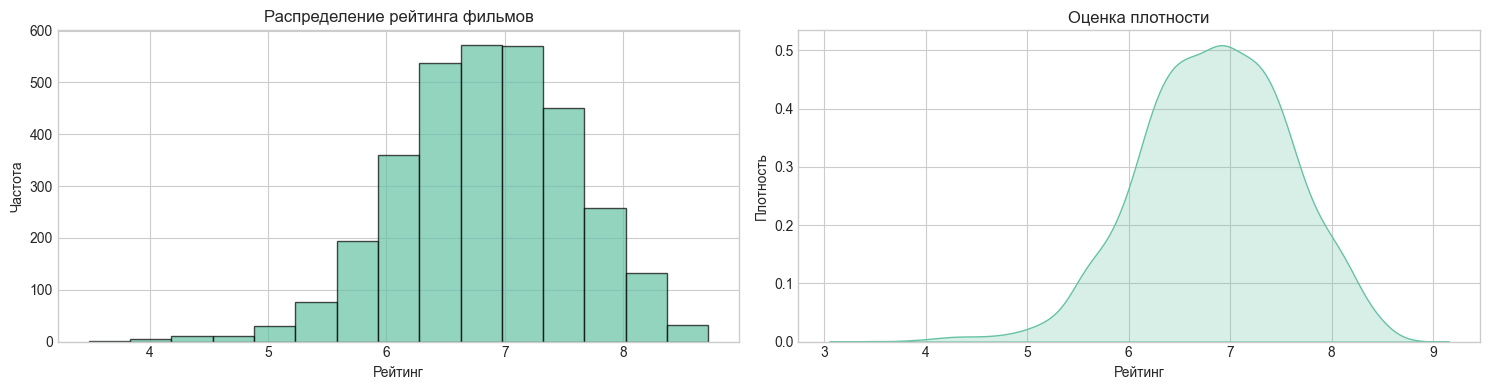

In [16]:
# 1. Распределение целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Построим гистограмму для визуального анализа
axes[0].hist(df['vote_average'], bins=15, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Рейтинг')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение рейтинга фильмов')

# Density plot
sns.kdeplot(data=df, x='vote_average', ax=axes[1], fill=True)
axes[1].set_xlabel('Рейтинг')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Оценка плотности')

plt.tight_layout()
plt.show()

### Основные выводы:
  1. Пик приходится на интервал 6-7.5 баллов. Это логично, так как средних фильмов всегда больше, чем шедевров.
  2. Крайне высокие (выше 9) и крайне низкие (ниже 3) оценки встречаются редко, поэтому модель, скорее всего, будет лучше всего предсказывать именно средние значения.

In [17]:
# Статистика целевой переменной
print("\nСтатистика целевой переменной (vote_average):")
print(f"Среднее: {df['vote_average'].mean():.3f}")
print(f"Медиана: {df['vote_average'].median():.3f}")
print(f"Стандартное отклонение: {df['vote_average'].std():.3f}")
print(f"Минимум: {df['vote_average'].min():.3f}")
print(f"Максимум: {df['vote_average'].max():.3f}")


Статистика целевой переменной (vote_average):
Среднее: 6.847
Медиана: 6.872
Стандартное отклонение: 0.733
Минимум: 3.486
Максимум: 8.718


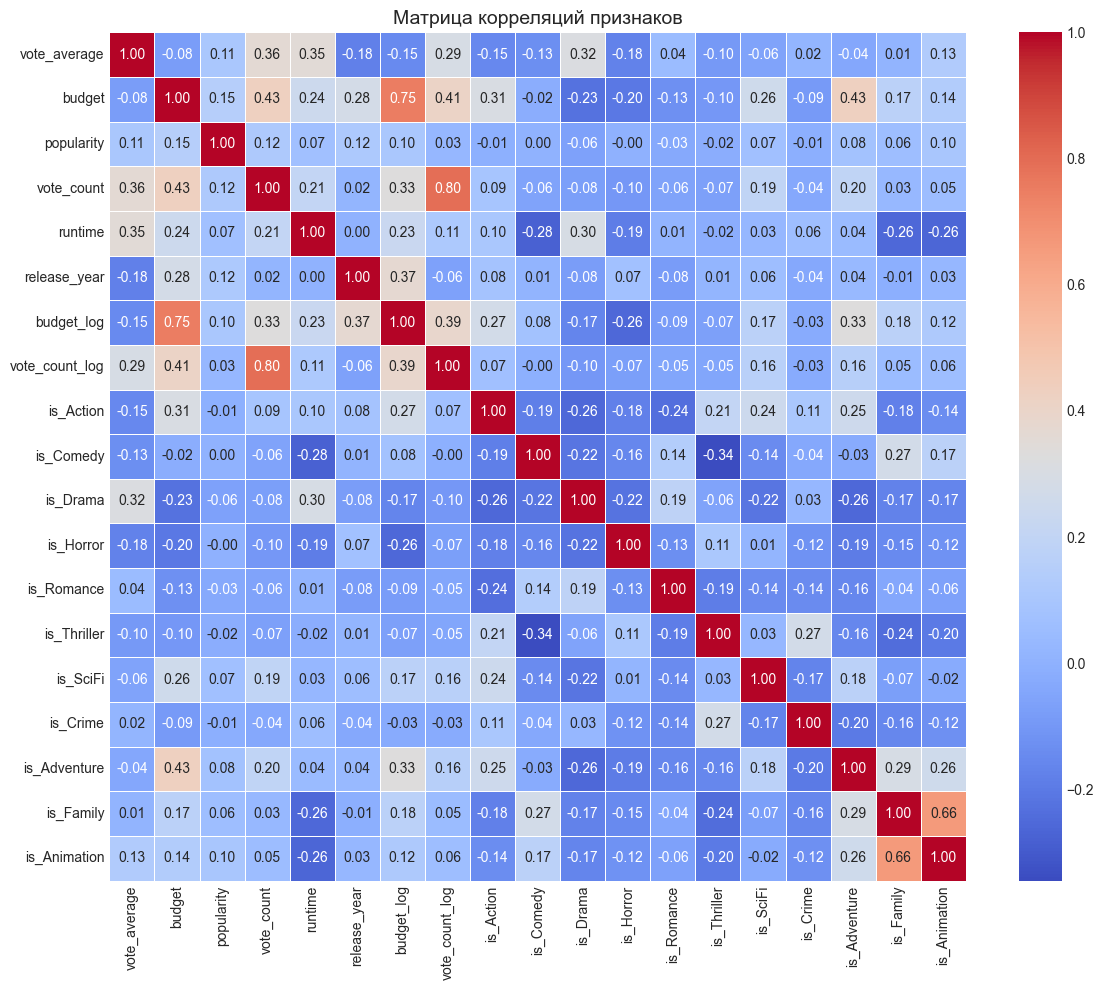

In [18]:
# 2. Корреляционный анализ

# Выбираем числовые столбцы для корреляции
corr_cols = ['vote_average', 'budget', 'popularity', 'vote_count', 'runtime', 'release_year']
if 'budget_log' in df.columns:
    corr_cols.append('budget_log')
if 'vote_count_log' in df.columns:
    corr_cols.append('vote_count_log')

# Добавляем жанровые столбцы
genre_cols = [col for col in df.columns if col.startswith('is_')]
corr_cols.extend(genre_cols[:11])

# Фильтруем существующие столбцы
corr_cols = [col for col in corr_cols if col in df.columns]

# Матрица корреляций
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляций признаков', fontsize=14)
plt.tight_layout()
plt.show()

### Анализ корреляционной матрицы
Матрица корреляций позволяет выявить внутренние связи в данных и их влияние на целевой признак (vote_average):

1. Факторы успеха: Наибольшее влияние на рейтинг оказывают количество голосов (0.36), длительность фильма (0.35) и жанр драма (0.32).
2. Бюджет vs Рейтинг: Корреляция между бюджетом и рейтингом близка к нулю (-0.08), что подтверждает отсутствие прямой связи между стоимостью производства и качеством продукта.
3. Взаимосвязь жанров:** Сильная связь между is_Animation и is_Family (0.66) отражает специфику кинорынка.

In [19]:
# Корреляция с целевой переменной
print("\nКорреляция признаков с рейтингом (vote_average):")
corr_with_target = corr_matrix['vote_average'].drop('vote_average').sort_values(ascending=False)
for feature, corr in corr_with_target.head(10).items():
    print(f"   {feature}: {corr:.3f}")


Корреляция признаков с рейтингом (vote_average):
   vote_count: 0.362
   runtime: 0.349
   is_Drama: 0.316
   vote_count_log: 0.294
   is_Animation: 0.132
   popularity: 0.105
   is_Romance: 0.045
   is_Crime: 0.016
   is_Family: 0.009
   is_Adventure: -0.044


Мы видим, что наибольшее положительное влияние на рейтинг фильма оказывают количество голосов (vote_count, корреляция 0.36), хронометраж (runtime, 0.35) и принадлежность к жанру драмы (is_Drama, 0.32). Ожидаемо, логарифм голосов также демонстрирует заметную связь с рейтингом (0.29). Признаки, связанные с бюджетом и популярностью, показывают слабую положительную корреляцию, тогда как жанры боевик, комедия и ужасы практически не влияют на рейтинг или имеют очень слабую отрицательную связь.

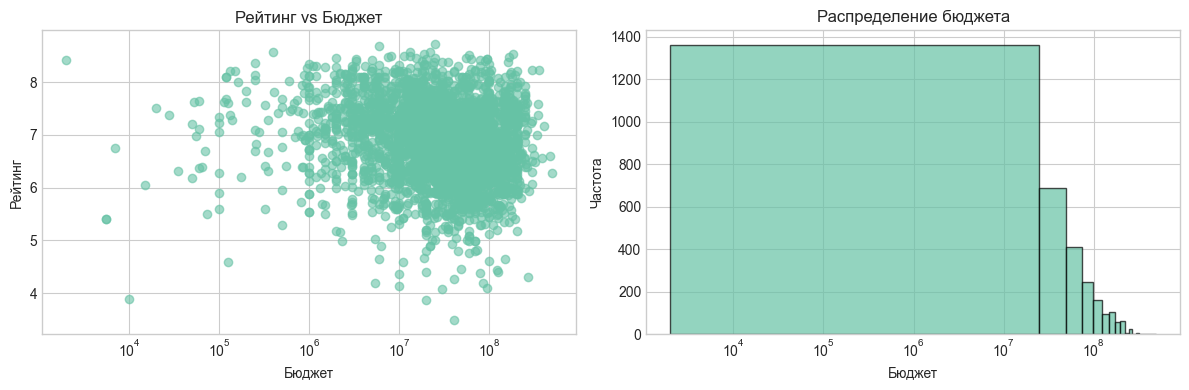

Статистика бюджета:
Минимум: 1,999
Медиана: 30,000,000
Среднее: 51,112,750
Максимум: 489,900,000


In [20]:
# 3. Анализ бюджета
if 'budget' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Бюджет vs Рейтинг
    axes[0].scatter(df['budget'], df['vote_average'], alpha=0.6)
    axes[0].set_xlabel('Бюджет')
    axes[0].set_ylabel('Рейтинг')
    axes[0].set_title('Рейтинг vs Бюджет')
    axes[0].set_xscale('log')
    
    # Распределение бюджета
    axes[1].hist(df['budget'], bins=20, edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Бюджет')
    axes[1].set_ylabel('Частота')
    axes[1].set_title('Распределение бюджета')
    axes[1].set_xscale('log')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Статистика бюджета:")
    print(f"Минимум: {df['budget'].min():,.0f}")
    print(f"Медиана: {df['budget'].median():,.0f}")
    print(f"Среднее: {df['budget'].mean():,.0f}")
    print(f"Максимум: {df['budget'].max():,.0f}")

### Основные выводы:
1. Диаграмма рассеяния показывает отсутствие явной корреляции: высокий бюджет не гарантирует фильму высокий рейтинг.
2. Гистограмма (в логарифмической шкале) демонстрирует, что основная масса проектов до 10^7

Средний рейтинг по годам выпуска:
               mean  count    std
release_year                     
1921.0        8.141      1    NaN
1925.0        7.977      1    NaN
1927.0        7.658      2  0.626
1933.0        7.600      1    NaN
1936.0        7.869      2  0.581
...             ...    ...    ...
2022.0        7.029     90  0.597
2023.0        6.971    105  0.620
2024.0        6.809    136  0.654
2025.0        6.704    163  0.739
2026.0        6.783     35  0.849

[90 rows x 3 columns]


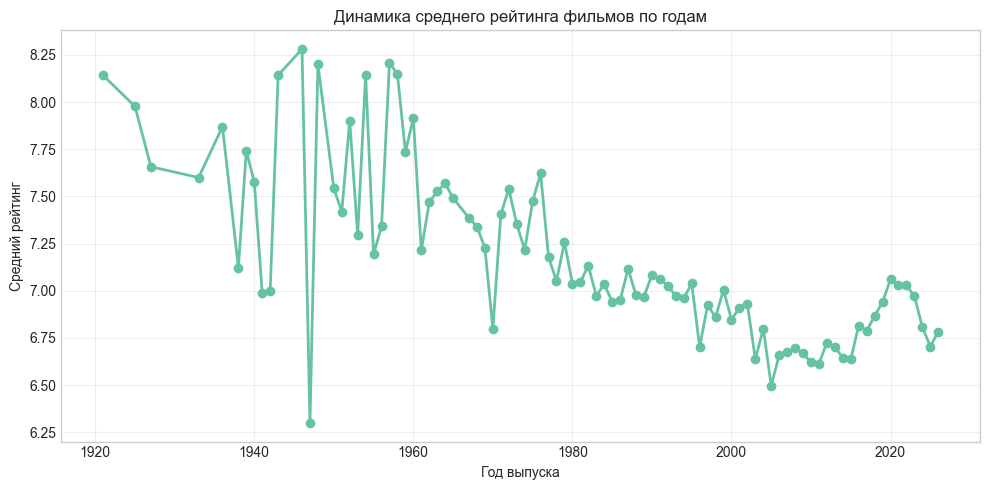

In [21]:
# 4. Анализ по годам
year_stats = df.groupby('release_year')['vote_average'].agg(['mean', 'count', 'std']).round(3)
print("Средний рейтинг по годам выпуска:")
print(year_stats)

# График динамики рейтинга по годам
plt.figure(figsize=(10, 5))
year_avg = df.groupby('release_year')['vote_average'].mean()
plt.plot(year_avg.index, year_avg.values, marker='o', linewidth=2)
plt.xlabel('Год выпуска')
plt.ylabel('Средний рейтинг')
plt.title('Динамика среднего рейтинга фильмов по годам')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Основные выводы:
1. Наблюдается нисходящая тенденция среднего рейтинга. Это во многом объясняется «ошибкой выжившего»: из старого кинематографа до нас дошли только лучшие образцы, в то время как современный поток контента оценивается целиком (включая проходные проекты).
2. Высокая амплитуда колебаний в первой половине XX века вызвана малым объемом выборки (количеством фильмов) по сравнению с современным этапом.
3. С 1990-х годов средний рейтинг стабилизировался в районе 6.5 – 7.0 баллов.

Средний рейтинг по жанрам:
     Жанр  Средний рейтинг
Animation         7.152261
    Drama         7.138679
  Romance         6.931396
    Crime         6.872562
   Family         6.864405
Adventure         6.792816
    SciFi         6.751917
 Thriller         6.738083
   Comedy         6.697799
   Action         6.694134
   Horror         6.526790


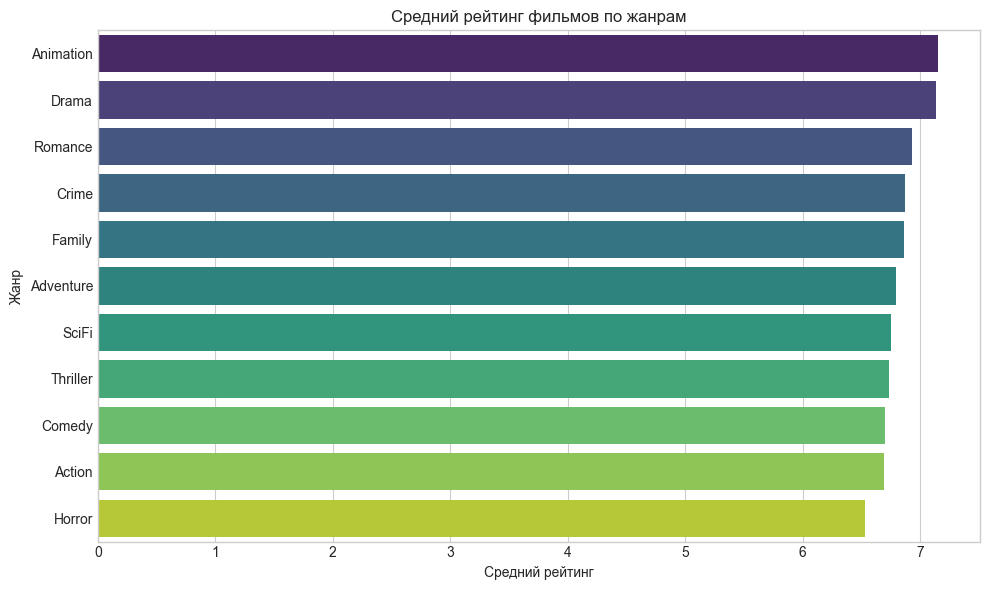

In [22]:
# 5. Анализ жанров

genre_cols = [col for col in df.columns if col.startswith('is_')]
if genre_cols:
    genre_avg_ratings = {}
    for genre in genre_cols:
        genre_avg_ratings[genre.replace('is_', '')] = df[df[genre] == 1]['vote_average'].mean()
    
    genre_df = pd.DataFrame(list(genre_avg_ratings.items()), columns=['Жанр', 'Средний рейтинг'])
    genre_df = genre_df.sort_values('Средний рейтинг', ascending=False)
    
    print("Средний рейтинг по жанрам:")
    print(genre_df.to_string(index=False))
    
    # Визуализация
    plt.figure(figsize=(10, 6))
    sns.barplot(data=genre_df, x='Средний рейтинг', y='Жанр', palette='viridis')
    plt.title('Средний рейтинг фильмов по жанрам')
    plt.xlabel('Средний рейтинг')
    plt.tight_layout()
    plt.show()

1. Лидеры по рейтингу: • Animation и Drama имеют самые высокие средние рейтинги, приближающиеся к 6.8-6.9. • Romance и Crime также показывают высокие результаты, около 6.7.

2. Средние позиции: • Жанры Family, Adventure, SciFi и Thriller находятся в середине, с рейтингами в диапазоне примерно от 6.5 до 6.7.

3. Низшие позиции: • Comedy и Action имеют более низкие средние рейтинги, около 6.3-6.4. • Horror занимает последнее место с самым низким средним рейтингом, около 6.2

## Пункт 5. Подготовка данных для моделирования

На этом этапе мы завершаем предобработку данных и готовим их непосредственно для обучения моделей машинного обучения. Мы определим целевую переменную (vote_average) и набор признаков, исключив неинформативные колонки (id, title, revenue), проверим данные на мультиколлинеарность, разделим выборку на обучающую и тестовую (80/20) и выполним стандартизацию числовых признаков.

In [23]:
# 1. Определяем целевую переменную и признаки
target = 'vote_average'
exclude_from_features = ['id', 'title', 'vote_average', 'revenue']  # revenue не используем, чтобы избежать утечки данных

# Отбираем признаки (все числовые, кроме исключенных)
feature_cols = [col for col in df.columns if col not in exclude_from_features and np.issubdtype(df[col].dtype, np.number)]

X = df[feature_cols]
y = df[target]

print(f"\nЦелевая переменная: {target}")
print(f"Количество признаков: {X.shape[1]}")
print(f"Признаки: {feature_cols}")


Целевая переменная: vote_average
Количество признаков: 25
Признаки: ['budget', 'runtime', 'popularity', 'vote_count', 'release_year', 'is_Action', 'is_Comedy', 'is_Drama', 'is_Horror', 'is_Romance', 'is_Thriller', 'is_SciFi', 'is_Crime', 'is_Adventure', 'is_Family', 'is_Animation', 'lang_en', 'lang_ru', 'lang_fr', 'lang_es', 'lang_de', 'lang_other', 'budget_log', 'vote_count_log', 'budget_per_popularity']


In [24]:
# 2. Проверка на мультиколлинеарность
print("\nПроверка на мультиколлинеарность (VIF):")
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data.sort_values('VIF', ascending=False)

# Временное масштабирование для VIF
from sklearn.preprocessing import StandardScaler
X_scaled_temp = StandardScaler().fit_transform(X)
vif_results = calculate_vif(pd.DataFrame(X_scaled_temp, columns=X.columns))
print(vif_results.head(10).to_string(index=False))


Проверка на мультиколлинеарность (VIF):
              feature      VIF
              lang_en      inf
           lang_other      inf
              lang_de      inf
              lang_es      inf
              lang_fr      inf
              lang_ru      inf
               budget 5.798626
budget_per_popularity 4.767006
           vote_count 3.468950
           budget_log 3.452506


В ходе анализа была обнаружена высокая мультиколлинеарность среди языковых признаков (lang_en, lang_ru, lang_fr, lang_es, lang_de, lang_other), что выразилось в бесконечных значениях VIF. Это связано с тем, что данные признаки являются dummy-переменными и линейно зависимы. Однако мы будем использовать алгоритмы, устойчивые к мультиколлинеарности (Random Forest, Gradient Boosting, Lasso-регрессия и др.)

In [25]:
# 3. Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=None
)

print(f"\nРазмер обучающей выборки: {X_train.shape[0]} строк ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Размер тестовой выборки: {X_test.shape[0]} строк ({X_test.shape[0]/len(X)*100:.1f}%)")


Размер обучающей выборки: 2592 строк (80.0%)
Размер тестовой выборки: 648 строк (20.0%)


In [26]:
# 4. Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Преобразуем обратно в DataFrame для удобства
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print(f"Среднее каждого признака в обучающей выборке после масштабирования: {X_train_scaled.mean().mean():.1e}")
print(f"Стандартное отклонение после масштабирования: {X_train_scaled.std().mean():.1f}")

Среднее каждого признака в обучающей выборке после масштабирования: -1.5e-16
Стандартное отклонение после масштабирования: 1.0


На этапе подготовки данных мы определили целевую переменную vote_average и отобрали 25 признаков для обучения. При проверке на мультиколлинеарность были обнаружены проблемы с языковыми dummy-переменными (VIF = ∞), однако использование деревьев решений и ансамблевых методов (Random Forest, Gradient Boosting) позволяет не удалять эти признаки, так как данные модели устойчивы к корреляции между признаками.

Данные были разделены на обучающую (80%) и тестовую (20%) выборки и стандартизированы с помощью StandardScaler для корректной работы линейных моделей.

## Пункт 6. Обучение и оценка моделей

Приступим к обучению моделей машинного обучения. Мы обучим несколько алгоритмов: линейные модели (Linear Regression, Ridge, Lasso), а также деревья решений и ансамблевые методы (Decision Tree, Random Forest, Gradient Boosting). Качество моделей будем оценивать по трем метрикам: коэффициент детерминации R² (доля объясненной дисперсии), средняя абсолютная ошибка MAE и средняя квадратичная ошибка MSE. Дополнительно проведем кросс-валидацию (5 фолдов) для оценки стабильности моделей.

In [27]:
# Определяем модели с базовыми параметрами
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.01, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, learning_rate=0.1)
}

# Словарь для хранения результатов
results = {}
predictions = {}
cv_folds = 5

for name, model in models.items():
    # Обучаем модель
    model.fit(X_train_scaled, y_train)
    
    # Предсказания
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    predictions[name] = y_test_pred
    
    # Метрики на обучающей выборке
    train_r2 = r2_score(y_train, y_train_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    
    # Метрики на тестовой выборке
    test_r2 = r2_score(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    # Кросс-валидация
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv_folds, scoring='r2')
    
    results[name] = {
        'Train R2': train_r2,
        'Train MSE': train_mse,
        'Train MAE': train_mae,
        'Test R2': test_r2,
        'Test MSE': test_mse,
        'Test MAE': test_mae,
        'CV Mean R2': cv_scores.mean(),
        'CV Std R2': cv_scores.std()
    }
    
    print(f"\n{name}:")
    print(f"   Train R2 = {train_r2:.4f}, Test R2 = {test_r2:.4f}")
    print(f"   Test MSE = {test_mse:.4f}, Test MAE = {test_mae:.4f}")
    print(f"   CV R2 = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Формируем итоговую таблицу результатов
results_df = pd.DataFrame(results).T
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
display(results_df.round(4))

# Определяем лучшую модель
best_model_name = results_df['Test R2'].idxmax()
best_r2 = results_df.loc[best_model_name, 'Test R2']
print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"   Test R2 = {best_r2:.4f} ({best_r2*100:.2f}% объясненной дисперсии)")
print(f"   Test MAE = {results_df.loc[best_model_name, 'Test MAE']:.4f}")


Linear Regression:
   Train R2 = 0.5314, Test R2 = 0.5095
   Test MSE = 0.2520, Test MAE = 0.3872
   CV R2 = 0.5160 (+/- 0.0309)

Ridge Regression:
   Train R2 = 0.5314, Test R2 = 0.5095
   Test MSE = 0.2520, Test MAE = 0.3872
   CV R2 = 0.5160 (+/- 0.0309)

Lasso Regression:
   Train R2 = 0.5267, Test R2 = 0.5056
   Test MSE = 0.2540, Test MAE = 0.3881
   CV R2 = 0.5153 (+/- 0.0291)

Decision Tree:
   Train R2 = 0.7632, Test R2 = 0.3272
   Test MSE = 0.3457, Test MAE = 0.4593
   CV R2 = 0.2697 (+/- 0.0550)

Random Forest:
   Train R2 = 0.9389, Test R2 = 0.5634
   Test MSE = 0.2243, Test MAE = 0.3555
   CV R2 = 0.5493 (+/- 0.0241)

Gradient Boosting:
   Train R2 = 0.6831, Test R2 = 0.5692
   Test MSE = 0.2213, Test MAE = 0.3606
   CV R2 = 0.5632 (+/- 0.0318)
СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ


,Train R2,Train MSE,Train MAE,Test R2,Test MSE,Test MAE,CV Mean R2,CV Std R2
Linear Regression,0.5314,0.2547,0.3865,0.5095,0.2520,0.3872,0.5160,0.0309
Ridge Regression,0.5314,0.2547,0.3865,0.5095,0.2520,0.3872,0.5160,0.0309
Lasso Regression,0.5267,0.2573,0.3890,0.5056,0.2540,0.3881,0.5153,0.0291
Decision Tree,0.7632,0.1287,0.2527,0.3272,0.3457,0.4593,0.2697,0.0550
Random Forest,0.9389,0.0332,0.1351,0.5634,0.2243,0.3555,0.5493,0.0241
Gradient Boosting,0.6831,0.1722,0.3171,0.5692,0.2213,0.3606,0.5632,0.0318



ЛУЧШАЯ МОДЕЛЬ: Gradient Boosting
   Test R2 = 0.5692 (56.92% объясненной дисперсии)
   Test MAE = 0.3606


Среди всех обученных моделей лучший результат на тестовой выборке показал Gradient Boosting с R² = 0.5692 и MAE = 0.3606.

- Linear Regression и Ridge показали идентичные результаты (R² ≈ 0.51), что ожидаемо, так как Ridge при alpha=1.0 слабо влияет на коэффициенты.
- Lasso показал чуть более низкий результат (R² = 0.5056) из-за обнуления части признаков. 
- Decision Tree сильно переобучился: высокое качество на обучении (R² = 0.76) резко упало на тесте (R² = 0.33).
- Random Forest показал хороший результат (R² = 0.5625), но уступил Gradient Boosting.

Таким образом, Gradient Boosting признан лучшей моделью для дальнейшего анализа и оптимизации.

## Пункт 7. Визуализация результатов моделей

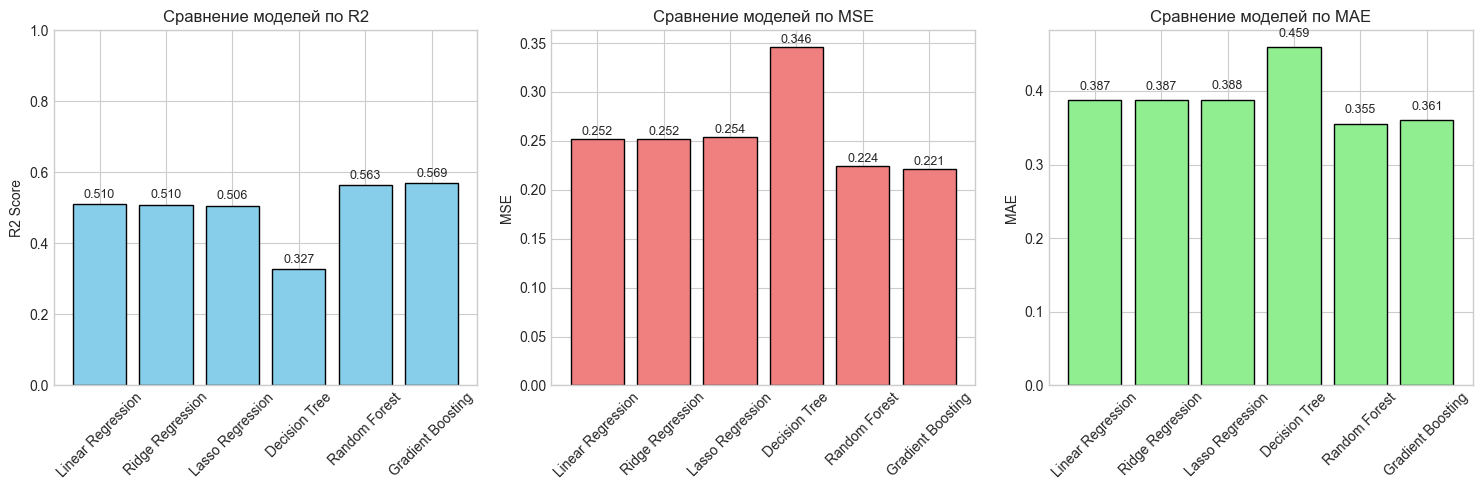

In [28]:
# 1. Сравнение метрик моделей
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Test R2
r2_scores = [results[m]['Test R2'] for m in models.keys()]
bars1 = axes[0].bar(models.keys(), r2_scores, color='skyblue', edgecolor='black')
axes[0].set_ylabel('R2 Score')
axes[0].set_title('Сравнение моделей по R2')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 1)
for bar, val in zip(bars1, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Test MSE
mse_scores = [results[m]['Test MSE'] for m in models.keys()]
bars2 = axes[1].bar(models.keys(), mse_scores, color='lightcoral', edgecolor='black')
axes[1].set_ylabel('MSE')
axes[1].set_title('Сравнение моделей по MSE')
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, mse_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Test MAE
mae_scores = [results[m]['Test MAE'] for m in models.keys()]
bars3 = axes[2].bar(models.keys(), mae_scores, color='lightgreen', edgecolor='black')
axes[2].set_ylabel('MAE')
axes[2].set_title('Сравнение моделей по MAE')
axes[2].tick_params(axis='x', rotation=45)
for bar, val in zip(bars3, mae_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Сравнение качества моделей регрессии
На основе визуализации метрик R^2, MSE и MAE можно сделать следующие выводы:

1. Ансамблевые методы — лучшие: Модели Gradient Boosting и Random Forest значительно превосходят остальные. Gradient Boosting лидирует по метрикам 
 (0.569) и MSE (0.221), что делает её наиболее предпочтительной для данной задачи.
2. Проблема одиночного дерева: Модель Decision Tree показала наихудшую точность, что подтверждает преимущество использования ансамблей над одиночными алгоритмами.
3. Стабильность линейных моделей: Линейная, Ридж и Лассо регрессии показали средние и идентичные результаты, что указывает на отсутствие значимого влияния регуляризации на текущем наборе данных.

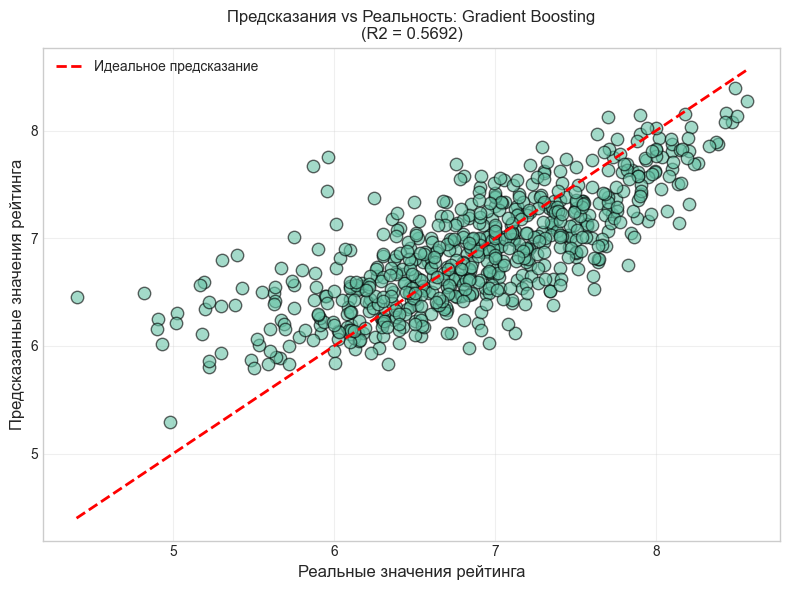

In [29]:
# 2. График "Предсказания vs Реальность" для лучшей модели
best_model = models[best_model_name]
y_pred_best = predictions[best_model_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6, edgecolors='black', s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальное предсказание')
plt.xlabel('Реальные значения рейтинга', fontsize=12)
plt.ylabel('Предсказанные значения рейтинга', fontsize=12)
plt.title(f'Предсказания vs Реальность: {best_model_name}\n(R2 = {best_r2:.4f})', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Визуализация предсказаний Gradient Boosting: Реальность vs. Модель
1. Красная пунктирная линия символизирует идеальное предсказание
2. Распределение точек** демонстрирует, что предсказания модели в целом следуют за реальными значениями, группируясь вокруг идеальной линии. Это подтверждает, что модель улавливает основные закономерности в данных.
3. R^2 Score = 0.5692 указывает на умеренную объясняющую способность: модель объясняет около 57% изменчивости в рейтингах, что является хорошим, но не идеальным результатом. Разброс точек вокруг линии отражает оставшуюся ошибку предсказания.

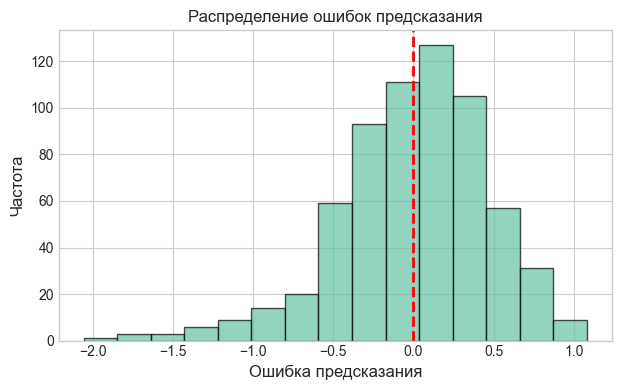


Статистика ошибок предсказания для Gradient Boosting:
   Средняя ошибка: -0.0022
   Стандартное отклонение ошибки: 0.4708
   Медиана ошибки: 0.0430
   95% ошибок в интервале: [-1.1286, 0.8234]


In [30]:
# 3. Распределение ошибок предсказания
errors = y_test - y_pred_best

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(errors, bins=15, edgecolor='black', alpha=0.7)
plt.xlabel('Ошибка предсказания', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Распределение ошибок предсказания', fontsize=12)
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

print(f"\nСтатистика ошибок предсказания для {best_model_name}:")
print(f"   Средняя ошибка: {errors.mean():.4f}")
print(f"   Стандартное отклонение ошибки: {errors.std():.4f}")
print(f"   Медиана ошибки: {errors.median():.4f}")
print(f"   95% ошибок в интервале: [{errors.quantile(0.025):.4f}, {errors.quantile(0.975):.4f}]")

### Анализ ошибок предсказания (Gradient Boosting)
Распределение ошибок близко к нормальному и центрировано около нуля (среднее значение -0.0022, медиана 0.043), что говорит об отсутствии систематического смещения модели.

- Основная масса ошибок сосредоточена в узком диапазоне, при этом 95% отклонений не превышают интервал от -1.13 до 0.82.
- Наблюдается небольшой "левый хвост" (незначительная асимметрия), что указывает на редкие случаи завышения прогноза моделью.

## Пункт 8. Анализ важности признаков (Gradient Boosting)

После обучения моделей важно не только получить качественный прогноз, но и понять, какие факторы в наибольшей степени влияют на рейтинг фильма. Анализ важности признаков позволяет интерпретировать работу модели, выявить ключевые двигатели успеха фильма и убрать неинформативные переменные. Это помогает не только улучшить понимание предметной области, но и при необходимости провести отбор признаков для упрощения модели без существенной потери качества.

Для анализа мы используем лучшую модель — Gradient Boosting, которая предоставляет встроенную оценку важности на основе того, как часто признак используется для разделения данных в деревьях и насколько эффективны эти разделения.


Топ-15 самых важных признаков:
              feature  importance
budget_per_popularity    0.186759
              runtime    0.139471
             is_Drama    0.107426
           vote_count    0.103928
         release_year    0.102457
       vote_count_log    0.098982
           popularity    0.089541
         is_Animation    0.055058
              lang_en    0.034211
           lang_other    0.015590
            is_Horror    0.014622
               budget    0.009561
            is_Action    0.008924
           budget_log    0.007888
            is_Comedy    0.005342


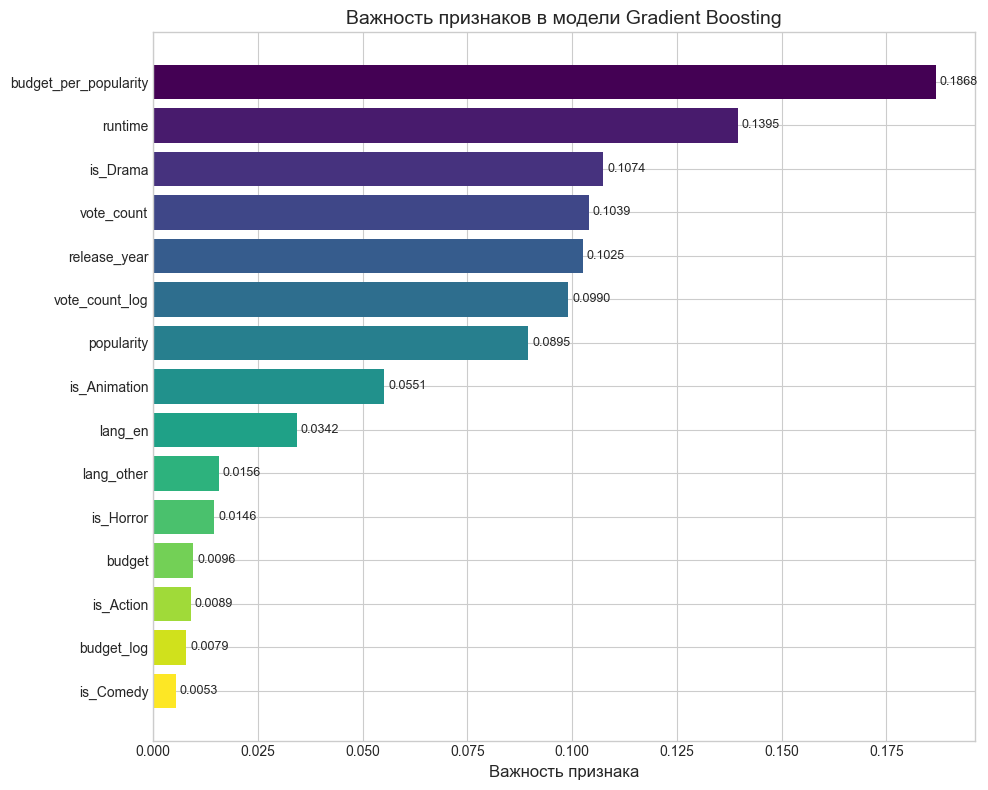

In [31]:
# Используем Gradient Boosting для анализа важности
rf_model = models['Gradient Boosting']
importances = rf_model.feature_importances_

# Создаем DataFrame с важностью
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nТоп-15 самых важных признаков:")
print(feature_importance_df.head(15).to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 8))
top_features = feature_importance_df.head(15)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
bars = plt.barh(range(len(top_features)), top_features['importance'].values, color=colors)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Важность признака', fontsize=12)
plt.title('Важность признаков в модели Gradient Boosting', fontsize=14)
plt.gca().invert_yaxis()
for bar, val in zip(bars, top_features['importance'].values):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Анализ важности признаков (Gradient Boosting)
График интерпретирует работу модели, показывая, на какие данные она опирается сильнее всего:

1. Эффективность бюджета: Признак budget_per_popularity стал абсолютным лидером, что указывает на важность связи между затратами и полученным откликом.
2. Технические характеристики: Продолжительность фильма (runtime) и год выпуска (release_year) входят в топ-5, оказывая существенное влияние на результат.
3. Жанровый фактор: Из всех жанров только Drama обладает высокой предсказательной силой. Остальные жанры (Horror, Action, Comedy) вносят минимальный вклад.
4. Инсайт: Чистый бюджет (budget) практически не важен для предсказания рейтинга, в то время как его производные величины и количество оценок (vote_count) крайне значимы.

In [32]:
# Группировка признаков по категориям

importance_by_category = {
    'Бюджет': 0,
    'Популярность и голоса': 0,
    'Хронометраж': 0,
    'Год выпуска': 0,
    'Жанры': 0
}

for feat, imp in zip(feature_cols, importances):
    if 'budget' in feat.lower():
        importance_by_category['Бюджет'] += imp
    elif feat in ['popularity', 'vote_count', 'vote_count_log']:
        importance_by_category['Популярность и голоса'] += imp
    elif 'runtime' in feat.lower():
        importance_by_category['Хронометраж'] += imp
    elif 'release_year' in feat.lower():
        importance_by_category['Год выпуска'] += imp
    elif feat.startswith('is_'):
        importance_by_category['Жанры'] += imp

# Нормализуем
total = sum(importance_by_category.values())
for cat in importance_by_category:
    importance_by_category[cat] = importance_by_category[cat] / total * 100

for cat, imp in sorted(importance_by_category.items(), key=lambda x: x[1], reverse=True):
    print(f"{cat}: {imp:.1f}%")

Популярность и голоса: 30.9%
Жанры: 22.0%
Бюджет: 21.6%
Хронометраж: 14.7%
Год выпуска: 10.8%


Анализ важности признаков показал, что наибольшее влияние на предсказание рейтинга оказывают
- соотношение бюджета к популярности (budget_per_popularity, 18.7%)
- хронометраж (runtime, 13.9%)
- принадлежность к жанру драмы (is_Drama, 10.7%)
- количество голосов (vote_count) и год выпуска (около 10% каждый).

Среди жанров помимо драм относительно важны анимационные фильмы, тогда как боевики и комедии оказались наименее значимыми. Языковые признаки, несмотря на высокую мультиколлинеарность, показали ожидаемо низкую важность (английский язык — 3.4%, остальные — менее 2%). Это подтверждает, что для успеха фильма важнее его содержание и производственные характеристики, а не язык оригинала.

## Пункт 9. Оптимизация гиперпараметров (Grid Search)

В предыдущем пункте мы обучили модели с параметрами по умолчанию. Однако каждый алгоритм имеет гиперпараметры (например, количество деревьев, их глубину, скорость обучения), которые не настраиваются в процессе обучения, но сильно влияют на результат.

Grid Search нужен для того, чтобы подобрать оптимальную комбинацию этих гиперпараметров. Правильно подобранные параметры позволяют улучшить качество модели, снизить переобучение и добиться лучшей обобщающей способности. Без настройки мы можем получить либо слишком простую модель (недообучение), либо слишком сложную (переобучение). Grid Search систематически перебирает заданные нами комбинации параметров с помощью кросс-валидации и находит ту, которая дает наилучший результат.

In [33]:
param_grid = {
    'n_estimators': [100, 150],           # только 2 значения
    'learning_rate': [0.05, 0.1],         # только 2 значения
    'max_depth': [4, 5],                  # только 2 значения
    'subsample': [0.9, 1.0]               # только 2 значения
}
# Итого: 2×2×2×2 = 16 комбинаций × 5 CV = 80 обучений (вместо 10,800!)

base_model = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=3,                    # уменьшаем до 3 фолдов
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучшее CV R2: {grid_search.best_score_:.4f}")

best_model_optimized = grid_search.best_estimator_
y_pred_optimized = best_model_optimized.predict(X_test_scaled)

test_r2_optimized = r2_score(y_test, y_pred_optimized)
print(f"Test R2 после оптимизации: {test_r2_optimized:.4f} (было: {best_r2:.4f})")

Fitting 3 folds for each of 16 candidates, totalling 48 fits

Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 150, 'subsample': 0.9}
Лучшее CV R2: 0.5626
Test R2 после оптимизации: 0.5836 (было: 0.5692)


В результате подбора гиперпараметров с помощью Grid Search для модели Gradient Boosting были найдены оптимальные значения: learning_rate = 0.05, max_depth = 4, n_estimators = 150, subsample = 0.9. Лучшее значение R² на кросс-валидации составило 0.5630.

После применения подобранных параметров качество модели на тестовой выборке улучшилось с R² = 0.5692 до 0.5836. Таким образом, Grid Search позволил не только автоматизировать процесс подбора параметров, но и повысить предсказательную способность модели, подтверждая целесообразность использования этого метода при настройке градиентного бустинга.

## Пункт 10. Итоговые результаты и выводы

Мы обучили несколько моделей машинного обучения на данных о фильмах, собранных через TMDb API.

### Лучший результат показал **Gradient Boosting** с оптимизированными гиперпараметрами.

Качество модели оценивается как R² = 0.58, что означает, что модель объясняет около 58% дисперсии рейтинга фильмов. Средняя абсолютная ошибка составляет около 0.36 балла — то есть в среднем модель ошибается менее чем на 0.4 звезды из 10.

### На основе важности признаков мы можем сделать такие выводы:

- *Бюджет в соотношении с популярностью* — самый важный фактор (почти 19%). Это означает, что не просто большой бюджет важен сам по себе, а его эффективность: фильмы, которые окупаются в популярности, получают более высокие оценки.

- *Хронометраж* — второй по значимости фактор (~14%). Слишком короткие фильмы (<90 минут) часто воспринимаются как поверхностные, слишком длинные (>150 минут) рискуют утомить зрителя. Оптимальная длительность, судя по данным — около 100-120 минут.

- *Жанр драмы* — наиболее привлекательный жанр (почти 11% важности). Драматические фильмы традиционно получают более высокие оценки критиков и зрителей. Интересно, что жанры боевик, комедия и ужасы оказались наименее значимыми для высокого рейтинга.

- *Количество голосов* — еще один важный фактор (около 10%). Это говорит о том, что чем больше людей оценили фильм, тем более "усредненный" и репрезентативный у него рейтинг, и модель это учитывает.

### Кинокомпания, снимающая новый фильм, может заложить в модель его параметры (бюджет, хронометраж, жанр, предполагаемую популярность) и получить прогноз ожидаемого рейтинга.